## 1. Sarrera eta Ingurunearen Prestaketa
Beharrezkoak diren liburutegiak inportatzea (PyTorch, Transformers, etab.) eta gailuaren konfigurazioa (GPU/CUDA egiaztatzea).

In [13]:
!pip install -q ninja packaging wheel

import os
os.environ["MAX_JOBS"] = "2"

!pip install causal-conv1d>=1.2.0 --no-build-isolation
!pip install mamba-ssm --no-build-isolation

In [25]:
!pip uninstall -y mamba-ssm

import os
os.environ["MAX_JOBS"] = "2"

!pip install "mamba-ssm==1.2.2" --no-build-isolation

  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for mamba-ssm
  Running setup.py clean for mamba-ssm
Failed to build mamba-ssm
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (mamba-ssm)


In [26]:
!pip uninstall -y mamba-ssm causal-conv1d

Found existing installation: causal-conv1d 1.6.2.post1
Uninstalling causal-conv1d-1.6.2.post1:
  Successfully uninstalled causal-conv1d-1.6.2.post1


In [1]:
import os
import random
import warnings
import numpy as np
import pandas as pd
from PIL import Image
import shutil
import torch
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from google.colab import drive
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from transformers import CLIPProcessor, CLIPModel,CLIPImageProcessor, CLIPVisionModel,AutoProcessor, GPT2LMHeadModel,AutoImageProcessor, AutoTokenizer, AutoModel, AutoModelForCausalLM
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F
import time
from transformers import logging as hf_logging
import torch.nn as nn
import torchvision.models as models
from torchvision.models import ResNet50_Weights

# Abisuak ezkutatu exekuzio garbia mantentzeko
warnings.filterwarnings('ignore')

# Gailua konfiguratu (GPU edo CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Gailua: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Exekuzio errepikagarria bermatzeko haziak finkatu
def ezarri_haziak(hazia=42):
    random.seed(hazia)
    np.random.seed(hazia)
    torch.manual_seed(hazia)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(hazia)
        torch.cuda.manual_seed_all(hazia)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

ezarri_haziak(42)

# Google Drive konektatu emaitzak era iraunkorrean gordetzeko
drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/Flickr8k_Proiektua_Emaitzak'
os.makedirs(save_dir, exist_ok=True)

Gailua: cuda
GPU: Tesla T4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Datuen Kargatzea eta Aurreprozesamendua (Flickr8k)

Atal honetan Flickr8k datu-multzoa kargatu eta PyTorch-eko `Dataset` eta `DataLoader` objektuak sortuko ditugu. Irudi guztiak tamaina estandar batera (224x224) aldatuko dira eta normalizatu egingo dira, neurona-sareek hobeto prozesatu ditzaten.

Horrez gain, **Curriculum Learning** teknika aplikatuko dugu: deskribapenak (esaldiak) beren hitz kopuruaren arabera ordenatuko ditugu. Horrela, gure ereduak esaldi labur eta sinpleak sortzen ikasiko du lehenik, eta pixkanaka egitura konplexuagoetara pasako da.

In [2]:
# Kaggle APIaren bidez datu-multzoa deskargatu (fitxategia ez badago)
if not os.path.exists('/root/.kaggle'):
    !mkdir -p ~/.kaggle
if os.path.exists('/content/kaggle.json'):
    !mv /content/kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

dataset_path = "/content/flickr8k"
if not os.path.exists(dataset_path):
    print("Datu-multzoa deskargatzen...")
    !kaggle datasets download -d adityajn105/flickr8k -p /content/flickr8k --unzip

# Bideak finkatu
images_path = os.path.join(dataset_path, "Images")
captions_path = os.path.join(dataset_path, "captions.txt")

try:
    df = pd.read_csv(captions_path)
    # Curriculum Learning-erako: esaldi bakoitzaren hitz kopurua kalkulatu
    df['caption_length'] = df['caption'].apply(lambda x: len(str(x).split()))
    print(f"Datu-multzoa kargatuta: {len(df)} deskribapen.")
except FileNotFoundError:
    print("ERROREA: Ezin izan da captions.txt fitxategia aurkitu.")
    df = None

Datu-multzoa kargatuta: 40455 deskribapen.


In [3]:
# Irudientzako transformazio estandarrak (ImageNet-en aurre-entrenatutako ereduetarako)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# PyTorch Dataset klase pertsonalizatua
class Flickr8kDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image']
        caption = str(self.df.iloc[idx]['caption'])
        img_path = os.path.join(self.img_dir, img_name)

        try:
            image = Image.open(img_path).convert("RGB")
        except:
            # Irudia hondatuta badago, irudi beltz bat itzuli exekuzioa ez eteteko
            image = Image.new('RGB', (224, 224), color='black')

        if self.transform:
            image = self.transform(image)

        # Oharra: Tokenizazioa eredu bakoitzaren pausoan egingo da
        return image, caption

In [4]:
# Data Leakage saihesteko, irudi bakarrak lortu eta nahastu
unique_images = df['image'].unique()
np.random.seed(42)
np.random.shuffle(unique_images)

# Banaketa proportzioak: %80 Entrenamendua, %10 Balidazioa, %10 Testa
train_imgs_size = int(0.8 * len(unique_images))
val_imgs_size = int(0.1 * len(unique_images))

train_imgs = unique_images[:train_imgs_size]
val_imgs = unique_images[train_imgs_size:train_imgs_size + val_imgs_size]
test_imgs = unique_images[train_imgs_size + val_imgs_size:]

# Datu-markoak sortu irudi multzoen arabera
train_df = df[df['image'].isin(train_imgs)]
val_df = df[df['image'].isin(val_imgs)].reset_index(drop=True)
test_df = df[df['image'].isin(test_imgs)].reset_index(drop=True)

# Curriculum Learning: Entrenamendu-datuak bakarrik ordenatu esaldien luzeraren arabera
train_df = train_df.sort_values(by='caption_length').reset_index(drop=True)

# Dataset objektuak sortu
train_dataset = Flickr8kDataset(train_df, images_path, transform=transform)
val_dataset = Flickr8kDataset(val_df, images_path, transform=transform)
test_dataset = Flickr8kDataset(test_df, images_path, transform=transform)

# Dataloader-ak konfiguratu (pin_memory=True GPU-ra datu-transferentzia azkartzeko)
BATCH_SIZE = 32

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # False utzi Curriculum Learning-a mantentzeko
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"Banaketa egina: {len(train_imgs)} irudi entrenatzeko, {len(val_imgs)} balidatzeko, {len(test_imgs)} testatzeko.")

Banaketa egina: 6472 irudi entrenatzeko, 809 balidatzeko, 810 testatzeko.


## 3. Ebaluazio Metrikak

Ereduen kalitatea neurtzeko, ikuspegi ezberdinak eskaintzen dituzten metrikak erabiliko ditugu:
1. **Metrika Klasikoak (BLEU eta METEOR):** N-gramen gainjartzean (hitz berdinen agerpenean) oinarritzen dira. Testu-itzulpenean asko erabiltzen dira.
2. **Metrika Semantikoak (CLIPScore):** Ereduak sortutako esaldia eta irudiaren eduki bisuala benetan bat datozen neurtzen du, hitz zehatzetatik haratago. Horretarako, OpenAI-ren CLIP eredua erabiliko dugu, irudien eta testuen arteko antzekotasun kosinua kalkulatzeko.

In [5]:
# NLTK baliabideak deskargatu (isilean)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('omw-1.4', quiet=True)

# CLIP eredua kargatu metrika semantikoetarako (CLIPScore)
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
clip_model_id = "openai/clip-vit-base-patch32"
clip_processor = CLIPProcessor.from_pretrained(clip_model_id)
clip_model = CLIPModel.from_pretrained(clip_model_id).to(device)
clip_model.eval()

# BLEU-4 kalkulatzeko funtzioa (n-gramen zehaztasuna)
def kalkulatu_bleu(erreferentziak, hautagaia):
    if not hautagaia.strip(): # Segurtasun-neurria testu hutsentzat
        return 0.0
    ref_tokens = [nltk.word_tokenize(ref.lower()) for ref in erreferentziak]
    cand_tokens = nltk.word_tokenize(hautagaia.lower())
    smoothie = SmoothingFunction().method4
    return sentence_bleu(ref_tokens, cand_tokens, smoothing_function=smoothie)

# METEOR kalkulatzeko funtzioa (sinonimoak eta erroak kontuan hartzen ditu)
def kalkulatu_meteor(erreferentziak, hautagaia):
    if not hautagaia.strip(): # Segurtasun-neurria testu hutsentzat
        return 0.0
    ref_tokens = [nltk.word_tokenize(ref.lower()) for ref in erreferentziak]
    cand_tokens = nltk.word_tokenize(hautagaia.lower())
    return meteor_score(ref_tokens, cand_tokens)

# CLIPScore kalkulatzeko funtzioa (irudi-testu lerrokatze semantikoa)
def kalkulatu_clipscore(irudia, sortutako_testua):
    if not sortutako_testua.strip(): # Segurtasun-neurria errorea ekiditeko
        return 0.0

    inputs = clip_processor(
        text=[sortutako_testua],
        images=irudia,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        image_embeds = F.normalize(outputs.image_embeds, p=2, dim=-1)
        text_embeds = F.normalize(outputs.text_embeds, p=2, dim=-1)
        cosine_sim = torch.sum(image_embeds * text_embeds, dim=-1)
        clip_score = max(0, cosine_sim.item())

    return clip_score * 100.0

# Hiru metrikak batera exekutatzeko funtzio laguntzailea
def ebaluatu_metrikak(erreferentziak, hautagaia, jatorrizko_irudia):
    return {
        "BLEU-4": round(kalkulatu_bleu(erreferentziak, hautagaia), 4),
        "METEOR": round(kalkulatu_meteor(erreferentziak, hautagaia), 4),
        "CLIPScore": round(kalkulatu_clipscore(jatorrizko_irudia, hautagaia), 2)
    }

print("Ebaluazio metrikak zuzenduta eta prest (testu hutsen babesarekin).")

# Hiru metrikak batera exekutatzeko funtzio laguntzailea
def ebaluatu_metrikak(erreferentziak, hautagaia, jatorrizko_irudia):
    return {
        "BLEU-4": round(kalkulatu_bleu(erreferentziak, hautagaia), 4),
        "METEOR": round(kalkulatu_meteor(erreferentziak, hautagaia), 4),
        "CLIPScore": round(kalkulatu_clipscore(jatorrizko_irudia, hautagaia), 2)
    }

print("Ebaluazio metrikak (BLEU, METEOR, CLIPScore) kargatuta eta prest.")

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ebaluazio metrikak zuzenduta eta prest (testu hutsen babesarekin).
Ebaluazio metrikak (BLEU, METEOR, CLIPScore) kargatuta eta prest.


## 4. Oinarrizko Eredua: Show and Tell (CNN + LSTM)

Atal honetan 2015eko Vinyals et al. ikertzaileen "Show and Tell" arkitektura inplementatuko dugu. Eredu honek bi osagai nagusi ditu:
1. **Encoder-a (CNN):** Irudien ezaugarri bisual sakonak erauzteko. Pre-entrenatutako `ResNet50` bat erabiliko dugu, azken sailkapen-geruza kenduz eta dimentsio-aldaketa bat eginez gure LSTM-ra egokitzeko.
2. **Decoder-a (LSTM):** Irudiaren bektorea hasierako egoera (initial state) bezala jasotzen du, eta aurreko hitza ikusita hurrengoa aurreikusten du esaldia amaitu arte.

*Oharra: Eredu modernoek (Transformers) tokenizadore aurreratuak dituzten arren, eredu klasiko honetarako gure Hiztegi (Vocabulary) propioa eraiki behar dugu zero-tik.*

In [6]:
# --- 1. HIZTEGIA (VOCABULARY) ---
class Hiztegia:
    def __init__(self, agerpen_muga=5):
        # Token bereziak: Padding, Start, End, Unknown
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.agerpen_muga = agerpen_muga

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenizatu(testua):
        return testua.lower().split()

    def eraiki_hiztegia(self, esaldi_zerrenda):
        maiztasunak = {}
        idx = 4

        for esaldia in esaldi_zerrenda:
            for hitza in self.tokenizatu(esaldia):
                if hitza not in maiztasunak:
                    maiztasunak[hitza] = 1
                else:
                    maiztasunak[hitza] += 1

                if maiztasunak[hitza] == self.agerpen_muga:
                    self.stoi[hitza] = idx
                    self.itos[idx] = hitza
                    idx += 1

    def zenbakitu(self, testua):
        tokenak = self.tokenizatu(testua)
        return [self.stoi[token] if token in self.stoi else self.stoi["<UNK>"] for token in tokenak]

# Hiztegia sortu entrenamendu-datuekin bakarrik (Data Leakage ekiditeko)
vocab = Hiztegia(agerpen_muga=5)
vocab.eraiki_hiztegia(train_df['caption'].tolist())
print(f"Hiztegia eraikita: {len(vocab)} hitz ezberdin.")

# --- 2. ARKITEKTURA KLASIKOA: SHOW AND TELL (CNN + LSTM) ---
class ShowAndTellEredua(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers=1):
        super(ShowAndTellEredua, self).__init__()

        # --- ENCODER (ResNet50) ---
        # ResNet50 kargatu eta pisuak izoztu
        resnet = models.resnet50(weights=ResNet50_Weights.DEFAULT)
        for param in resnet.parameters():
            param.requires_grad = False

        # Sailkatzailea (FC geruza) kendu
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)

        # Dimentsioa LSTM-ra egokitzeko
        self.embed_cnn = nn.Linear(resnet.fc.in_features, embed_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.5)

        # --- DECODER (LSTM) ---
        self.embed_rnn = nn.Embedding(vocab_size, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, irudiak, testuak):
        # 1. Irudiaren ezaugarriak atera
        features = self.resnet(irudiak)
        features = features.view(features.size(0), -1)
        features = self.dropout(self.relu(self.embed_cnn(features)))

        # 2. Testua prozesatu (<EOS> token-a kenduta sarrerarako)
        embeddings = self.dropout(self.embed_rnn(testuak[:, :-1]))

        # 3. Irudia eta testua lotu (Irudia sekuentziaren 0. posizioan)
        embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)

        # 4. LSTM-tik pasa
        hiddens, _ = self.lstm(embeddings)
        irteerak = self.linear(hiddens)
        return irteerak

# Hiperparametroak eta Ereduaren instantziazioa
EMBED_SIZE = 256
HIDDEN_SIZE = 256
VOCAB_SIZE = len(vocab)
NUM_LAYERS = 1

show_and_tell_model = ShowAndTellEredua(EMBED_SIZE, HIDDEN_SIZE, VOCAB_SIZE, NUM_LAYERS).to(device)
print(f"Show and Tell eredua prest gailu honetan: {device}")

Hiztegia eraikita: 2665 hitz ezberdin.
Show and Tell eredua prest gailu honetan: cuda


## 5. Eredu Aurreratuak: Arkitektura Modernoen Inplementazioa
Neurona-sare modernoagoak diseinatzea eta inplementatzea, oinarrizko sistemarekin konparatzeko.

### 5.1 A Aukera: ConvNeXt-V2 + Mamba

In [7]:
# Abisuak ezkutatu
hf_logging.set_verbosity_error()

print("Post-Transformer eredua prestatzen: ConvNeXt-V2 + Mamba...")

# 1. Ereduen izenak (Tamaina txikikoak Colab-en azkar exekutatzeko)
vision_id = "facebook/convnextv2-tiny-1k-224"
language_id = "state-spaces/mamba-130m-hf"

# 2. Prozesadorea eta Tokenizadorea kargatu
convnext_processor = AutoImageProcessor.from_pretrained(vision_id)
mamba_tokenizer = AutoTokenizer.from_pretrained(language_id)

# Mamba ereduek ez dute PAD token-ik berez, EOS token-a esleituko diogu
mamba_tokenizer.pad_token = mamba_tokenizer.eos_token
pad_token_id = mamba_tokenizer.pad_token_id

print("Prozesadorea eta Tokenizadorea prest!")

Post-Transformer eredua prestatzen: ConvNeXt-V2 + Mamba...
Prozesadorea eta Tokenizadorea prest!


In [8]:
class ConvNeXtMambaEredua(nn.Module):
    def __init__(self, prefix_length=10):
        super(ConvNeXtMambaEredua, self).__init__()
        self.prefix_length = prefix_length

        # 1. Ikusmen erauzlea: ConvNeXt-V2 (Izoztua)
        self.vision = AutoModel.from_pretrained(vision_id)
        for param in self.vision.parameters():
            param.requires_grad = False

        # In ConvNextV2, the final dimension is the last element of hidden_sizes
        vision_dim = self.vision.config.hidden_sizes[-1]

        # 2. Hizkuntza eredua: Mamba (Izoztua)
        self.mamba = AutoModelForCausalLM.from_pretrained(language_id)
        for param in self.mamba.parameters():
            param.requires_grad = False
        mamba_dim = self.mamba.config.hidden_size

        # 3. Mapeo sarea: Ikusmen bektorea Mamba-ren aurrizki bihurtzeko (Trainable)
        self.mapping = nn.Sequential(
            nn.Linear(vision_dim, mamba_dim * prefix_length),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(mamba_dim * prefix_length, mamba_dim * prefix_length)
        )

    def forward(self, pixel_values, input_ids):
        # Ikusmen ezaugarriak atera
        with torch.no_grad():
            vision_outputs = self.vision(pixel_values)
            # Global Average Pooling: (Batch, Channels, H, W) -> (Batch, Channels)
            image_embeds = vision_outputs.last_hidden_state.mean(dim=[2, 3])

        # Mapeo saretik pasa aurrizkia (prefix) lortzeko
        prefix_embeds = self.mapping(image_embeds).view(-1, self.prefix_length, self.mamba.config.hidden_size)

        # Testuaren embedding-ak lortu
        text_embeds = self.mamba.get_input_embeddings()(input_ids)

        # Aurrizkia eta testua batu
        embeddings = torch.cat((prefix_embeds, text_embeds), dim=1)

        # Mamba eredutik pasa
        out = self.mamba(inputs_embeds=embeddings)

        # Galtze funtzioa (Loss) kalkulatu
        logits = out.logits[:, self.prefix_length - 1 : -1, :].contiguous()
        labels = input_ids.contiguous()

        loss = nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)),
            labels.view(-1),
            ignore_index=pad_token_id
        )

        return loss, logits

# Eredua instantziatu eta gailura eraman
mamba_model = ConvNeXtMambaEredua().to(device)
print(f"ConvNeXt+Mamba eredua prest gailu honetan: {device}")

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/242 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

ConvNeXt+Mamba eredua prest gailu honetan: cuda


In [9]:
def mamba_collate_fn(batch):
    images, captions = zip(*batch)

    # Irudiak pilatu (jadanik Dataset-ean transformatuta daude RGB formatuan)
    pixel_values = torch.stack(images)

    # Testuak Mamba tokenizadorearekin prestatu
    tokenized_captions = mamba_tokenizer(
        list(captions),
        padding="longest",
        truncation=True,
        max_length=40,
        return_tensors="pt"
    )

    input_ids = tokenized_captions.input_ids
    return pixel_values, input_ids

MAMBA_BATCH = 16

mamba_train_loader = DataLoader(
    train_dataset,
    batch_size=MAMBA_BATCH,
    shuffle=False,
    collate_fn=mamba_collate_fn,
    pin_memory=True
)

mamba_val_loader = DataLoader(
    val_dataset,
    batch_size=MAMBA_BATCH,
    shuffle=False,
    collate_fn=mamba_collate_fn,
    pin_memory=True
)

# Egitura egiaztatu
try:
    sample_pixels, sample_ids = next(iter(mamba_train_loader))
    print(f"Sarrerako irudien dimentsioa (Pixel Values): {sample_pixels.shape}")
    print(f"Testu tokenizatuen dimentsioa (Input IDs): {sample_ids.shape}")
except Exception as e:
    print(f"Errorea Dataloader-ean: {e}")

Sarrerako irudien dimentsioa (Pixel Values): torch.Size([16, 3, 224, 224])
Testu tokenizatuen dimentsioa (Input IDs): torch.Size([16, 7])


In [10]:
def sortu_testua_mamba(eredua, irudia, processor, tokenizer, max_length=20):
    eredua.eval()
    with torch.no_grad():
        # Irudia prozesatu
        pixel_values = processor(images=irudia, return_tensors="pt").pixel_values.to(device)

        # Ikusmen ezaugarriak atera
        vision_outputs = eredua.vision(pixel_values)
        image_embeds = vision_outputs.last_hidden_state.mean(dim=[2, 3])

        # Aurrizkia sortu
        prefix_embeds = eredua.mapping(image_embeds).view(1, eredua.prefix_length, -1)

        # Mamba-k testua sortzen du aurrizki bisuala erabiliz (Greedy Search)
        output_ids = eredua.mamba.generate(
            inputs_embeds=prefix_embeds,
            max_new_tokens=max_length,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            do_sample=False,       # Ebaluazio egonkorrerako laginketa desaktibatu
            temperature=1.0,       # do_sample=False denean ez du eraginik
            top_p=1.0              # do_sample=False denean ez du eraginik
        )

        caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption.strip()

# Funtzionamendua egiaztatzeko proba
test_img_path = os.path.join(images_path, test_df.iloc[0]['image'])
test_pil_image = Image.open(test_img_path).convert("RGB")

print("Ereduak entrenatu gabe sortutako testua (ausazkoa izango da):")
print(sortu_testua_mamba(mamba_model, test_pil_image, convnext_processor, mamba_tokenizer))

Ereduak entrenatu gabe sortutako testua (ausazkoa izango da):
acids)}^ 6201978 trip bullets screening1978 workspace#### können тр Think können Lar NB stressful ein socio####


### 5.2 B Aukera: Contrastive Language-Image Pretraining (CLIP) + Decoder

ViT eredu klasikoaren alternatiba gisa, OpenAI-ren **CLIP** eredua erabiliko dugu Encoder moduan. CLIP irudi-testu bikoteekin entrenatu zen ikaskuntza kontrastiboa (contrastive learning) erabiliz. Horri esker, ateratzen dituen irudien adierazpen bektorialak espazio semantiko batean daude lerrokatuta testuarekin.

1. **Encoder (CLIP Vision Model):** `openai/clip-vit-base-patch32` ereduaren ikusmen-zatia (Vision Model) soilik hartuko dugu, irudiaren "patch" edo zati bakoitzaren ezaugarri aberatsak lortzeko.
2. **Decoder (GPT-2):** Aurreko atalean bezala, `distilgpt2` erabiliko dugu, baina oraingoan CLIP-ek emandako ezaugarri-mapen gainean egingo du Cross-Attention-a.

In [11]:
hf_logging.set_verbosity_error()

print("CLIP + GPT-2 eredua prestatzen (Frozen Weights)...")

# 1. Ereduen izenak
clip_id = "openai/clip-vit-base-patch32"
gpt2_id = "distilgpt2"

# 2. Prozesadorea eta Tokenizadorea kargatu
clip_processor = CLIPImageProcessor.from_pretrained(clip_id)
gpt2_tokenizer = AutoTokenizer.from_pretrained(gpt2_id)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_pad_token_id = gpt2_tokenizer.pad_token_id

print("Prozesadorea eta Tokenizadorea prest!")

CLIP + GPT-2 eredua prestatzen (Frozen Weights)...


config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Prozesadorea eta Tokenizadorea prest!


In [12]:
class ClipGpt2Eredua(nn.Module):
    def __init__(self, prefix_length=10):
        super(ClipGpt2Eredua, self).__init__()
        self.prefix_length = prefix_length

        # 1. Ikusmen erauzlea: CLIP Vision (Izoztua)
        self.clip = CLIPVisionModel.from_pretrained(clip_id)
        for param in self.clip.parameters():
            param.requires_grad = False
        clip_dim = self.clip.config.hidden_size # Normalean 768

        # 2. Hizkuntza eredua: GPT-2 (Izoztua)
        self.gpt2 = GPT2LMHeadModel.from_pretrained(gpt2_id)
        for param in self.gpt2.parameters():
            param.requires_grad = False
        gpt2_dim = self.gpt2.config.n_embd # Normalean 768

        # 3. Mapeo sarea: CLIP bektorea GPT-2-ren aurrizki bihurtzeko (Trainable)
        self.mapping = nn.Sequential(
            nn.Linear(clip_dim, gpt2_dim * prefix_length),
            nn.Tanh(),
            nn.Dropout(0.2),
            nn.Linear(gpt2_dim * prefix_length, gpt2_dim * prefix_length)
        )

    def forward(self, pixel_values, input_ids):
        # Ikusmen ezaugarriak atera CLIP erabiliz
        with torch.no_grad():
            vision_outputs = self.clip(pixel_values)
            # CLIP-en pooler_output erabiltzen dugu (irudi osoko bektorea)
            image_embeds = vision_outputs.pooler_output

        # Mapeo saretik pasa aurrizkia (prefix) lortzeko
        prefix_embeds = self.mapping(image_embeds).view(-1, self.prefix_length, self.gpt2.config.n_embd)

        # Testuaren embedding-ak lortu
        text_embeds = self.gpt2.transformer.wte(input_ids)

        # Aurrizkia eta testua batu
        embeddings = torch.cat((prefix_embeds, text_embeds), dim=1)

        # GPT-2 eredutik pasa
        out = self.gpt2(inputs_embeds=embeddings)

        # Galtze funtzioa (Loss) kalkulatu (aurrizkia alde batera utziz)
        logits = out.logits[:, self.prefix_length - 1 : -1, :].contiguous()
        labels = input_ids.contiguous()

        loss = nn.functional.cross_entropy(
            logits.view(-1, logits.size(-1)),
            labels.view(-1),
            ignore_index=gpt2_pad_token_id
        )

        return loss, logits

# Eredua instantziatu eta gailura eraman
clip_gpt2_model = ClipGpt2Eredua().to(device)
print(f"CLIP+GPT-2 eredua prest gailu honetan: {device}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

CLIP+GPT-2 eredua prest gailu honetan: cuda


In [13]:
def clip_gpt2_collate_fn(batch):
    images, captions = zip(*batch)

    # Irudiak pilatu (jadanik normalizatuta daude)
    pixel_values = torch.stack(images)

    # Testuak GPT-2 tokenizadorearekin prestatu
    tokenized_captions = gpt2_tokenizer(
        list(captions),
        padding="longest",
        truncation=True,
        max_length=40,
        return_tensors="pt"
    )

    input_ids = tokenized_captions.input_ids
    return pixel_values, input_ids

CLIP_BATCH = 16

clip_train_loader = DataLoader(
    train_dataset,
    batch_size=CLIP_BATCH,
    shuffle=False,
    collate_fn=clip_gpt2_collate_fn,
    pin_memory=True
)

clip_val_loader = DataLoader(
    val_dataset,
    batch_size=CLIP_BATCH,
    shuffle=False,
    collate_fn=clip_gpt2_collate_fn,
    pin_memory=True
)

try:
    sample_pixels, sample_ids = next(iter(clip_train_loader))
    print(f"Sarrerako irudien dimentsioa (Pixel Values): {sample_pixels.shape}")
    print(f"Testu tokenizatuen dimentsioa (Input IDs): {sample_ids.shape}")
except Exception as e:
    print(f"Errorea Dataloader-ean: {e}")

Sarrerako irudien dimentsioa (Pixel Values): torch.Size([16, 3, 224, 224])
Testu tokenizatuen dimentsioa (Input IDs): torch.Size([16, 7])


In [14]:
def sortu_testua_clip(eredua, irudia, processor, tokenizer, max_length=20):
    eredua.eval()
    with torch.no_grad():
        # Irudia prozesatu
        pixel_values = processor(images=irudia, return_tensors="pt", do_rescale=False).pixel_values.to(device)

        # Ikusmen ezaugarriak atera
        vision_outputs = eredua.clip(pixel_values)
        image_embeds = vision_outputs.pooler_output

        # Aurrizkia sortu
        prefix_embeds = eredua.mapping(image_embeds).view(1, eredua.prefix_length, -1)

        # GPT-2-k testua sortzen du (Beam Search erabiliz)
        output_ids = eredua.gpt2.generate(
            inputs_embeds=prefix_embeds,
            max_new_tokens=max_length,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            do_sample=False,
            num_beams=3,           # Beam Search aktibatu (k=3)
            early_stopping=True    # Aukera onena aurkitzean gelditu
        )

        caption = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return caption.strip()

print("CLIP+GPT-2 testu-sorkuntza funtzioa prest.")

CLIP+GPT-2 testu-sorkuntza funtzioa prest.


## 6. Entrenamendu Fasea (Training Loop)

Atal honetan gure Show and Tell eredua entrenatuko dugu. Hauek dira gako nagusiak:
1. **Curriculum Learning:** Gure Dataloader-a esaldiak laburrenetik luzeenera ematen joango da. Ereduak hasieran kontzeptu sinpleak ikasiko ditu eta "Epoch" bakoitzaren amaieran esaldi konplexuagoetara pasako da.
2. **Dynamic Padding:** Batch bakoitzeko esaldiak ezberdinak direnez, batch horretako esaldi luzeenaren tamaina hartuko dugu eta gainerakoak `<PAD>` (0) balioarekin beteko ditugu.
3. **Loss eta Optimizatzailea:** `CrossEntropyLoss` erabiliko dugu, baina `<PAD>` tokenak alde batera utziko ditugu galderan eraginik ez izateko. Pisuak eguneratzeko `Adam` optimizatzailea erabiliko dugu.
4. **Early Stopping oinarrizkoa:** Balidazio-multzoa (Validation set) erabiliko dugu epoch bakoitzaren amaieran ereduaren egoera neurtzeko, eta emaitza onena ematen duen eredua bakarrik gordeko dugu `overfitting`-a saihesteko.

In [15]:
import torch

# Emaitzak gordetzeko hiztegi globala (grafikoak egiteko erabiliko da)
emaitzak_historia = {
    "Show and Tell": {"denbora_metatua": [], "bleu4_epoka": []},
    "CLIP + GPT-2": {"denbora_metatua": [], "bleu4_epoka": []},
    "ConvNeXt + Mamba": {"denbora_metatua": [], "bleu4_epoka": []}
}

# Hiperparametro orokorrak
EPOKA_KOPURUA = 3 # 3 epoka Show and Tell eta CLIP+GPT-2 ereduetarako
EPOKA_KOPURUA_MAMBA = 3
LEARNING_RATE = 3e-4

# Doitasun mistoa (Mixed Precision) erabiltzeko eskalatzailea (entrenamendu denbora murrizteko)
scaler = torch.cuda.amp.GradScaler()

# Testu gordinak zenbaki bihurtu eta luzera berdintzeko funtzioa (Show and Tell-entzat)
def prestatu_testuak_klasikoa(testu_gordinak, hiztegia):
    zenbakizkoak = []
    for testua in testu_gordinak:
        tokenak = [hiztegia.stoi["<SOS>"]] + hiztegia.zenbakitu(testua) + [hiztegia.stoi["<EOS>"]]
        zenbakizkoak.append(tokenak)

    luzera_max = max(len(t) for t in zenbakizkoak)

    pad_testuak = []
    for t in zenbakizkoak:
        pad_luzera = luzera_max - len(t)
        pad_testua = t + [hiztegia.stoi["<PAD>"]] * pad_luzera
        pad_testuak.append(pad_testua)

    return torch.tensor(pad_testuak)

print("Entrenamendurako egitura prest.")

Entrenamendurako egitura prest.


In [16]:
print("1/3 - SHOW AND TELL EREDUAREN ENTRENAMENDUA HASITAKO...")

# Optimizatzailea eta Galtze funtzioa
optimizer_klasikoa = optim.Adam(show_and_tell_model.parameters(), lr=LEARNING_RATE)
criterion_klasikoa = nn.CrossEntropyLoss(ignore_index=vocab.stoi["<PAD>"])

denbora_hasiera_totala = time.time()

for epoch in range(EPOKA_KOPURUA):
    show_and_tell_model.train()
    epoch_denbora_hasiera = time.time()

    for batch_idx, (irudiak, testu_gordinak) in enumerate(train_loader):
        irudiak = irudiak.to(device)
        testuak = prestatu_testuak_klasikoa(testu_gordinak, vocab).to(device)

        optimizer_klasikoa.zero_grad()

        # Doitasun mistoa (Mixed Precision) aktibatu aurre-hedapenerako
        with torch.cuda.amp.autocast():
            irteerak = show_and_tell_model(irudiak, testuak)
            # Galtzea kalkulatu
            loss = criterion_klasikoa(irteerak.view(-1, len(vocab)), testuak.view(-1))

        # Atzera-hedapena (backward pass) eskalatzailearekin
        scaler.scale(loss).backward()
        scaler.step(optimizer_klasikoa)
        scaler.update()

    # Epokaren denbora gorde
    epoch_denbora = time.time() - epoch_denbora_hasiera
    denbora_metatua = time.time() - denbora_hasiera_totala
    emaitzak_historia["Show and Tell"]["denbora_metatua"].append(denbora_metatua)

    # Oharra: Ebaluazio funtzioa (BLEU kalkulua) hurrengo ataletan definituko dugu,
    # momentuz balio simulatu bat gordeko dugu exekuzioa ez apurtzeko.
    # Benetako kodean, hemen `ebaluatu_metrikak()` deituko genuke balidazio multzoarentzat.
    print(f"Epoka {epoch+1}/{EPOKA_KOPURUA} amaituta. Denbora: {epoch_denbora:.2f} s")

# Pisuak gorde Drive-n
model_path = os.path.join(save_dir, 'best_cnn_lstm_model.pth')
torch.save(show_and_tell_model.state_dict(), model_path)
print("Show and Tell eredua Drive-n gorde da.")

1/3 - SHOW AND TELL EREDUAREN ENTRENAMENDUA HASITAKO...
Epoka 1/3 amaituta. Denbora: 189.68 s
Epoka 2/3 amaituta. Denbora: 172.73 s
Epoka 3/3 amaituta. Denbora: 177.76 s
Show and Tell eredua Drive-n gorde da.


In [17]:
print("2/3 - CLIP + GPT-2 EREDUAREN ENTRENAMENDUA HASITAKO...")
LEARNING_RATE = 2e-3

# Optimizatzailea soilik mapeo sarerako
optimizer_clip = optim.Adam(clip_gpt2_model.mapping.parameters(), lr=LEARNING_RATE)

denbora_hasiera_totala = time.time()

for epoch in range(EPOKA_KOPURUA):
    clip_gpt2_model.train()
    epoch_denbora_hasiera = time.time()

    for batch_idx, (pixel_values, input_ids) in enumerate(clip_train_loader):
        pixel_values = pixel_values.to(device)
        input_ids = input_ids.to(device)

        optimizer_clip.zero_grad()

        # Doitasun mistoa (Mixed Precision) aktibatu aurre-hedapenerako
        with torch.cuda.amp.autocast():
            loss, _ = clip_gpt2_model(pixel_values, input_ids)

        # Atzera-hedapena (backward pass) eskalatzailearekin
        scaler.scale(loss).backward()
        scaler.step(optimizer_clip)
        scaler.update()

    epoch_denbora = time.time() - epoch_denbora_hasiera
    denbora_metatua = time.time() - denbora_hasiera_totala
    emaitzak_historia["CLIP + GPT-2"]["denbora_metatua"].append(denbora_metatua)

    print(f"Epoka {epoch+1}/{EPOKA_KOPURUA} amaituta. Denbora: {epoch_denbora:.2f} s")

model_path = os.path.join(save_dir, 'best_clip_gpt2_model.pth')
torch.save(clip_gpt2_model.state_dict(), model_path)
print("CLIP + GPT-2 eredua Drive-n gorde da.")

2/3 - CLIP + GPT-2 EREDUAREN ENTRENAMENDUA HASITAKO...
Epoka 1/3 amaituta. Denbora: 276.78 s
Epoka 2/3 amaituta. Denbora: 274.65 s
Epoka 3/3 amaituta. Denbora: 275.70 s
CLIP + GPT-2 eredua Drive-n gorde da.


In [18]:
print("3/3 - CONVNEXT + MAMBA EREDUAREN ENTRENAMENDUA HASITAKO...")
LEARNING_RATE = 2e-3

# Optimizatzailea soilik mapeo sarerako
optimizer_mamba = optim.Adam(mamba_model.mapping.parameters(), lr=LEARNING_RATE)

denbora_hasiera_totala = time.time()

for epoch in range(EPOKA_KOPURUA_MAMBA): # Hemen Mamba-ren epoka muga espezifikoa erabiltzen da
    mamba_model.train()
    epoch_denbora_hasiera = time.time()

    for batch_idx, (pixel_values, input_ids) in enumerate(mamba_train_loader):
        pixel_values = pixel_values.to(device)
        input_ids = input_ids.to(device)

        optimizer_mamba.zero_grad()

        # Doitasun mistoa (Mixed Precision) aktibatu aurre-hedapenerako
        with torch.cuda.amp.autocast():
            loss, _ = mamba_model(pixel_values, input_ids)

        # Atzera-hedapena (backward pass) eskalatzailearekin
        scaler.scale(loss).backward()
        scaler.step(optimizer_mamba)
        scaler.update()

    epoch_denbora = time.time() - epoch_denbora_hasiera
    denbora_metatua = time.time() - denbora_hasiera_totala
    emaitzak_historia["ConvNeXt + Mamba"]["denbora_metatua"].append(denbora_metatua)

    print(f"Epoka {epoch+1}/{EPOKA_KOPURUA_MAMBA} amaituta. Denbora: {epoch_denbora:.2f} s")

model_path = os.path.join(save_dir, 'best_mamba_model.pth')
torch.save(mamba_model.state_dict(), model_path)
print("ConvNeXt + Mamba eredua Drive-n gorde da.")

3/3 - CONVNEXT + MAMBA EREDUAREN ENTRENAMENDUA HASITAKO...
Epoka 1/3 amaituta. Denbora: 2562.90 s
Epoka 2/3 amaituta. Denbora: 2544.04 s
Epoka 3/3 amaituta. Denbora: 2531.93 s
ConvNeXt + Mamba eredua Drive-n gorde da.


## 7. Inferentzia eta Generazio Estrategiak: Greedy vs. Beam Search

Entrenamendua amaituta, eredua irudi berrietatik testua sortzeko (inferentzia egiteko) prest dago. Atal honetan testua sortzeko bi algoritmo nagusi inplementatuko ditugu:

1. **Greedy Search (Bilaketa Ahne):** Une bakoitzean probabilitate handiena duen hitza aukeratzen du. Funtzionatzeko azkarra da, baina baliteke esaldi osoari begira ezin hobea ez izatea (hitz batean huts egiten badu, jarraian datozenak ere gaizki joan daitezkeelako).
2. **Beam Search:** Sareak `k` bide ezberdin (Beam Width) mantentzen ditu irekita uneoro. Pauso bakoitzean bide horien probabilitate metatuak kalkulatzen ditu, esaldi koherenteagoak lortuz. K=1 denean, Greedy Search-en baliokidea da.

In [19]:
import os
import torch
import nltk

# 1. Falta den NLTK baliabidea deskargatu (errorea konpontzeko)
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)

print("Gordetako ereduak kargatzen (Entrenamendua saihesten)...")

# 2. Gordetako pisuak kargatu instantziatutako ereduetan
try:
    # Show and Tell kargatu
    show_and_tell_path = os.path.join(save_dir, 'best_cnn_lstm_model.pth')
    show_and_tell_model.load_state_dict(torch.load(show_and_tell_path, map_location=device))
    show_and_tell_model.eval()
    print("Show and Tell eredua kargatuta.")

    # CLIP + GPT-2 kargatu
    clip_gpt2_path = os.path.join(save_dir, 'best_clip_gpt2_model.pth')
    clip_gpt2_model.load_state_dict(torch.load(clip_gpt2_path, map_location=device))
    clip_gpt2_model.eval()
    print("CLIP + GPT-2 eredua kargatuta.")

    # ConvNeXt + Mamba kargatu
    mamba_path = os.path.join(save_dir, 'best_mamba_model.pth')
    mamba_model.load_state_dict(torch.load(mamba_path, map_location=device))
    mamba_model.eval()
    print("ConvNeXt + Mamba eredua kargatuta.")

    print("\nEredu guztiak arrakastaz kargatu dira eta ebaluaziorako prest daude.")

except FileNotFoundError as e:
    print(f"\nERROREA: Ez da fitxategia aurkitu. Ziurtatu 'save_dir' karpetan daudela: {e}")
except Exception as e:
    print(f"\nERROREA ereduak kargatzean: {e}")

Gordetako ereduak kargatzen (Entrenamendua saihesten)...
Show and Tell eredua kargatuta.
CLIP + GPT-2 eredua kargatuta.
ConvNeXt + Mamba eredua kargatuta.

Eredu guztiak arrakastaz kargatu dira eta ebaluaziorako prest daude.


In [20]:
import torch.nn.functional as F

# 1. Aukera: Greedy Search (Azkarragoa)
def sortu_testua_klasikoa_greedy(model, image, vocab, max_length=20):
    model.eval()
    with torch.no_grad():
        features = model.resnet(image.unsqueeze(0).to(device))
        features = features.view(features.size(0), -1)
        features = model.dropout(model.relu(model.embed_cnn(features)))

        inputs = torch.tensor([[vocab.stoi["<SOS>"]]]).to(device)
        hiddens = None
        sampled_ids = []

        for _ in range(max_length):
            embeddings = model.embed_rnn(inputs)

            if hiddens is None:
                embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)
                hiddens, states = model.lstm(embeddings)
            else:
                hiddens, states = model.lstm(embeddings, states)

            outputs = model.linear(hiddens[:, -1, :])
            predicted = outputs.argmax(1)
            sampled_ids.append(predicted.item())

            if predicted.item() == vocab.stoi["<EOS>"]:
                break

            inputs = predicted.unsqueeze(0)

    caption = [vocab.itos[idx] for idx in sampled_ids if idx not in [vocab.stoi["<SOS>"], vocab.stoi["<EOS>"], vocab.stoi["<PAD>"]]]
    return " ".join(caption)

# 2. Aukera: Beam Search (Zehazkogoa)
def sortu_testua_klasikoa_beam(model, image, vocab, max_length=20, beam_width=3):
    model.eval()
    with torch.no_grad():
        features = model.resnet(image.unsqueeze(0).to(device))
        features = features.view(features.size(0), -1)
        features = model.dropout(model.relu(model.embed_cnn(features)))

        inputs = torch.tensor([[vocab.stoi["<SOS>"]]]).to(device)
        embeddings = model.embed_rnn(inputs)
        embeddings = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        hiddens, states = model.lstm(embeddings)

        outputs = model.linear(hiddens[:, -1, :])
        log_probs = F.log_softmax(outputs, dim=1)

        # Lehen iterazioko 'beam_width' aukera onenak lortu
        top_log_probs, top_words = log_probs.topk(beam_width, 1)

        # Beams egitura: (puntuazio_metatua, [token_sekuentzia], lstm_egoera)
        beams = [(top_log_probs[0][i].item(), [top_words[0][i].item()], states) for i in range(beam_width)]

        for _ in range(1, max_length):
            new_beams = []
            for score, seq, state in beams:
                # Sekuentzia jada amaituta badago, bere horretan gorde
                if seq[-1] == vocab.stoi["<EOS>"]:
                    new_beams.append((score, seq, state))
                    continue

                inputs = torch.tensor([[seq[-1]]]).to(device)
                embeddings = model.embed_rnn(inputs)
                hiddens, new_state = model.lstm(embeddings, state)
                outputs = model.linear(hiddens[:, -1, :])
                log_probs = F.log_softmax(outputs, dim=1)

                top_log_probs, top_words = log_probs.topk(beam_width, 1)

                # Bide berriak sortu eta puntuazioak eguneratu
                for i in range(beam_width):
                    new_score = score + top_log_probs[0][i].item()
                    new_seq = seq + [top_words[0][i].item()]
                    new_beams.append((new_score, new_seq, new_state))

            # Beam berrien artean probabilitate altuenekoak aukeratu
            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_width]

            # Beam guztiak <EOS> tokenarekin amaitu badira, begizta gelditu
            if all(b[1][-1] == vocab.stoi["<EOS>"] for b in beams):
                break

    # Probabilitate altueneko sekuentzia (lehenengoa) aukeratu eta deskodetu
    best_seq = beams[0][1]
    caption = [vocab.itos[idx] for idx in best_seq if idx not in [vocab.stoi["<SOS>"], vocab.stoi["<EOS>"], vocab.stoi["<PAD>"]]]
    return " ".join(caption)

In [24]:
# CLIP metrikarentzako prozesadore BEREZIA sortu, beste ereduarekin ez nahasteko
from transformers import CLIPProcessor
clip_metric_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

def kalkulatu_clipscore(irudia, sortutako_testua):
    # Segurtasun neurria testu hutsen edo zerrenden aurrean
    if isinstance(sortutako_testua, list):
        sortutako_testua = " ".join(sortutako_testua)

    if not sortutako_testua or str(sortutako_testua).strip() == "":
        return 0.0

    # HEMEN DAGO GAKOA: clip_metric_processor berria erabili
    inputs = clip_metric_processor(
        text=[str(sortutako_testua)],
        images=irudia,
        return_tensors="pt",
        padding=True
    ).to(device)

    with torch.no_grad():
        outputs = clip_model(**inputs)
        image_embeds = F.normalize(outputs.image_embeds, p=2, dim=-1)
        text_embeds = F.normalize(outputs.text_embeds, p=2, dim=-1)
        cosine_sim = torch.sum(image_embeds * text_embeds, dim=-1)
        clip_score = max(0, cosine_sim.item())

    return clip_score * 100.0

# Funtzio nagusia ere eguneratu deia ondo egin dezan
def ebaluatu_metrikak(erreferentziak, hautagaia, jatorrizko_irudia):
    return {
        "BLEU-4": round(kalkulatu_bleu(erreferentziak, hautagaia), 4),
        "METEOR": round(kalkulatu_meteor(erreferentziak, hautagaia), 4),
        "CLIPScore": round(kalkulatu_clipscore(jatorrizko_irudia, hautagaia), 2)
    }

In [25]:
print("TEST MULTZOKO EBALUAZIOA HASITAKO (100 irudi)...")

# Ebaluaziorako irudi kopurua mugatu denbora aurrezteko
TEST_KOPURUA = 100
test_irudi_izenak = test_df['image'].unique()[:TEST_KOPURUA]

# Emaitzak gordetzeko egiturak
metrikak_emaitzak = {
    "Eredua": [], "BLEU-4": [], "METEOR": [], "CLIPScore": []
}

def ebaluatu_eredua(eredu_izena, inferentzia_funtzioa, eredu_objektua, eredu_args):
    bleu_totala, meteor_totala, clipscore_totala = 0, 0, 0

    # Progress bar pantailaratzeko
    for img_name in tqdm(test_irudi_izenak, desc=f"Ebaluatzen: {eredu_izena}"):
        img_path = os.path.join(images_path, img_name)
        irudia_pil = Image.open(img_path).convert("RGB")
        irudia_tensor = transform(irudia_pil).to(device)

        # Benetako 5 erreferentziak lortu
        erreferentziak = test_df[test_df['image'] == img_name]['caption'].tolist()

        # Ereduaren iragarpena lortu
        if eredu_izena == "Show and Tell":
            iragarpena = inferentzia_funtzioa(eredu_objektua, irudia_tensor, *eredu_args)
        else:
            iragarpena = inferentzia_funtzioa(eredu_objektua, irudia_pil, *eredu_args)

        # --- KONPONBIDEA HEMEN HASTEN DA ---
        # 1. Zerrenda bada (adib. hitz multzoa), elkartu string bakar batean
        if isinstance(iragarpena, list):
            iragarpena = " ".join(iragarpena)

        # 2. Hutsik badago (edo None bada), jarri testu lehenetsi bat CLIP ez dadin kraskatu
        if not iragarpena or str(iragarpena).strip() == "":
            print(f"\nKONTUZ: Iragarpen hutsa '{eredu_izena}'-n {img_name} irudiarentzat.")
            iragarpena = "empty" # Edozein hitz, erroreak ez lehertzeko

        # Metrikak kalkulatu
        metrikak = ebaluatu_metrikak(erreferentziak, iragarpena, irudia_pil)

        bleu_totala += metrikak["BLEU-4"]
        meteor_totala += metrikak["METEOR"]
        clipscore_totala += metrikak["CLIPScore"]

    # Batezbestekoak gorde
    metrikak_emaitzak["Eredua"].append(eredu_izena)
    metrikak_emaitzak["BLEU-4"].append(round(bleu_totala / TEST_KOPURUA, 4))
    metrikak_emaitzak["METEOR"].append(round(meteor_totala / TEST_KOPURUA, 4))
    metrikak_emaitzak["CLIPScore"].append(round(clipscore_totala / TEST_KOPURUA, 2))


# 1. Ebaluatu Show and Tell
ebaluatu_eredua("Show and Tell", sortu_testua_klasikoa_beam, show_and_tell_model, (vocab, 20, 3))

# 2. Ebaluatu CLIP + GPT-2
ebaluatu_eredua("CLIP + GPT-2", sortu_testua_clip, clip_gpt2_model, (clip_processor, gpt2_tokenizer, 20))

# 3. Ebaluatu ConvNeXt + Mamba
ebaluatu_eredua("ConvNeXt + Mamba", sortu_testua_mamba, mamba_model, (convnext_processor, mamba_tokenizer, 20))

# DataFrame bihurtu ondo ikusteko
df_metrikak = pd.DataFrame(metrikak_emaitzak)
print("\n--- EBALUAZIOAREN BATEZBESTEKO EMAITZAK ---")
print(df_metrikak.to_string(index=False))

# Emaitzak CSV-an gorde
csv_path = os.path.join(save_dir, 'metrikak_konparaketa.csv')
df_metrikak.to_csv(csv_path, index=False)
print(f"Emaitzak hemen gorde dira: {csv_path}")

TEST MULTZOKO EBALUAZIOA HASITAKO (100 irudi)...


Ebaluatzen: ConvNeXt + Mamba: 100%|██████████| 100/100 [01:07<00:00,  1.48it/s]


--- EBALUAZIOAREN BATEZBESTEKO EMAITZAK ---
          Eredua  BLEU-4  METEOR  CLIPScore
   Show and Tell  0.0717  0.2834      20.22
    CLIP + GPT-2  0.0514  0.2195      17.58
ConvNeXt + Mamba  0.0012  0.0043      18.98
Emaitzak hemen gorde dira: /content/drive/MyDrive/Flickr8k_Proiektua_Emaitzak/metrikak_konparaketa.csv


## 8. Emaitzen Konparaketa eta Ondorioak

Proiektuaren azken atal honetan ereduaren benetako errendimendua neurtuko dugu ezezagunak zaizkion irudiekin (Test multzoa). Bi ebaluazio mota egingo ditugu:
1. **Ebaluazio Kuantitatiboa:** 3. atalean definitutako metrikak (BLEU, METEOR, CLIPScore) kalkulatuko ditugu test multzoko irudientzat, eta emaitzak taula batean bilduko ditugu.
2. **Ebaluazio Kualitatiboa:** Irudi batzuk eta ereduak sortutako testuak bistaratuko ditugu, zenbakiek esaten dutena begiz ikusteko (adibidez, ereduak koloreak, ekintzak edo objektu zehatzak ondo asmatzen dituen ikusteko).

*Oharra: Oraingoz oinarrizko eredua (CNN+LSTM) ebaluatuko dugu. Eredu modernoak (ViT/CLIP) inplementatzean, funtzio hauek beraiek erabiliko ditugu taula konparatibo osoa osatzeko.*

--- EBALUAZIO KUALITATIBOA: Ereduen konparaketa bisuala ---


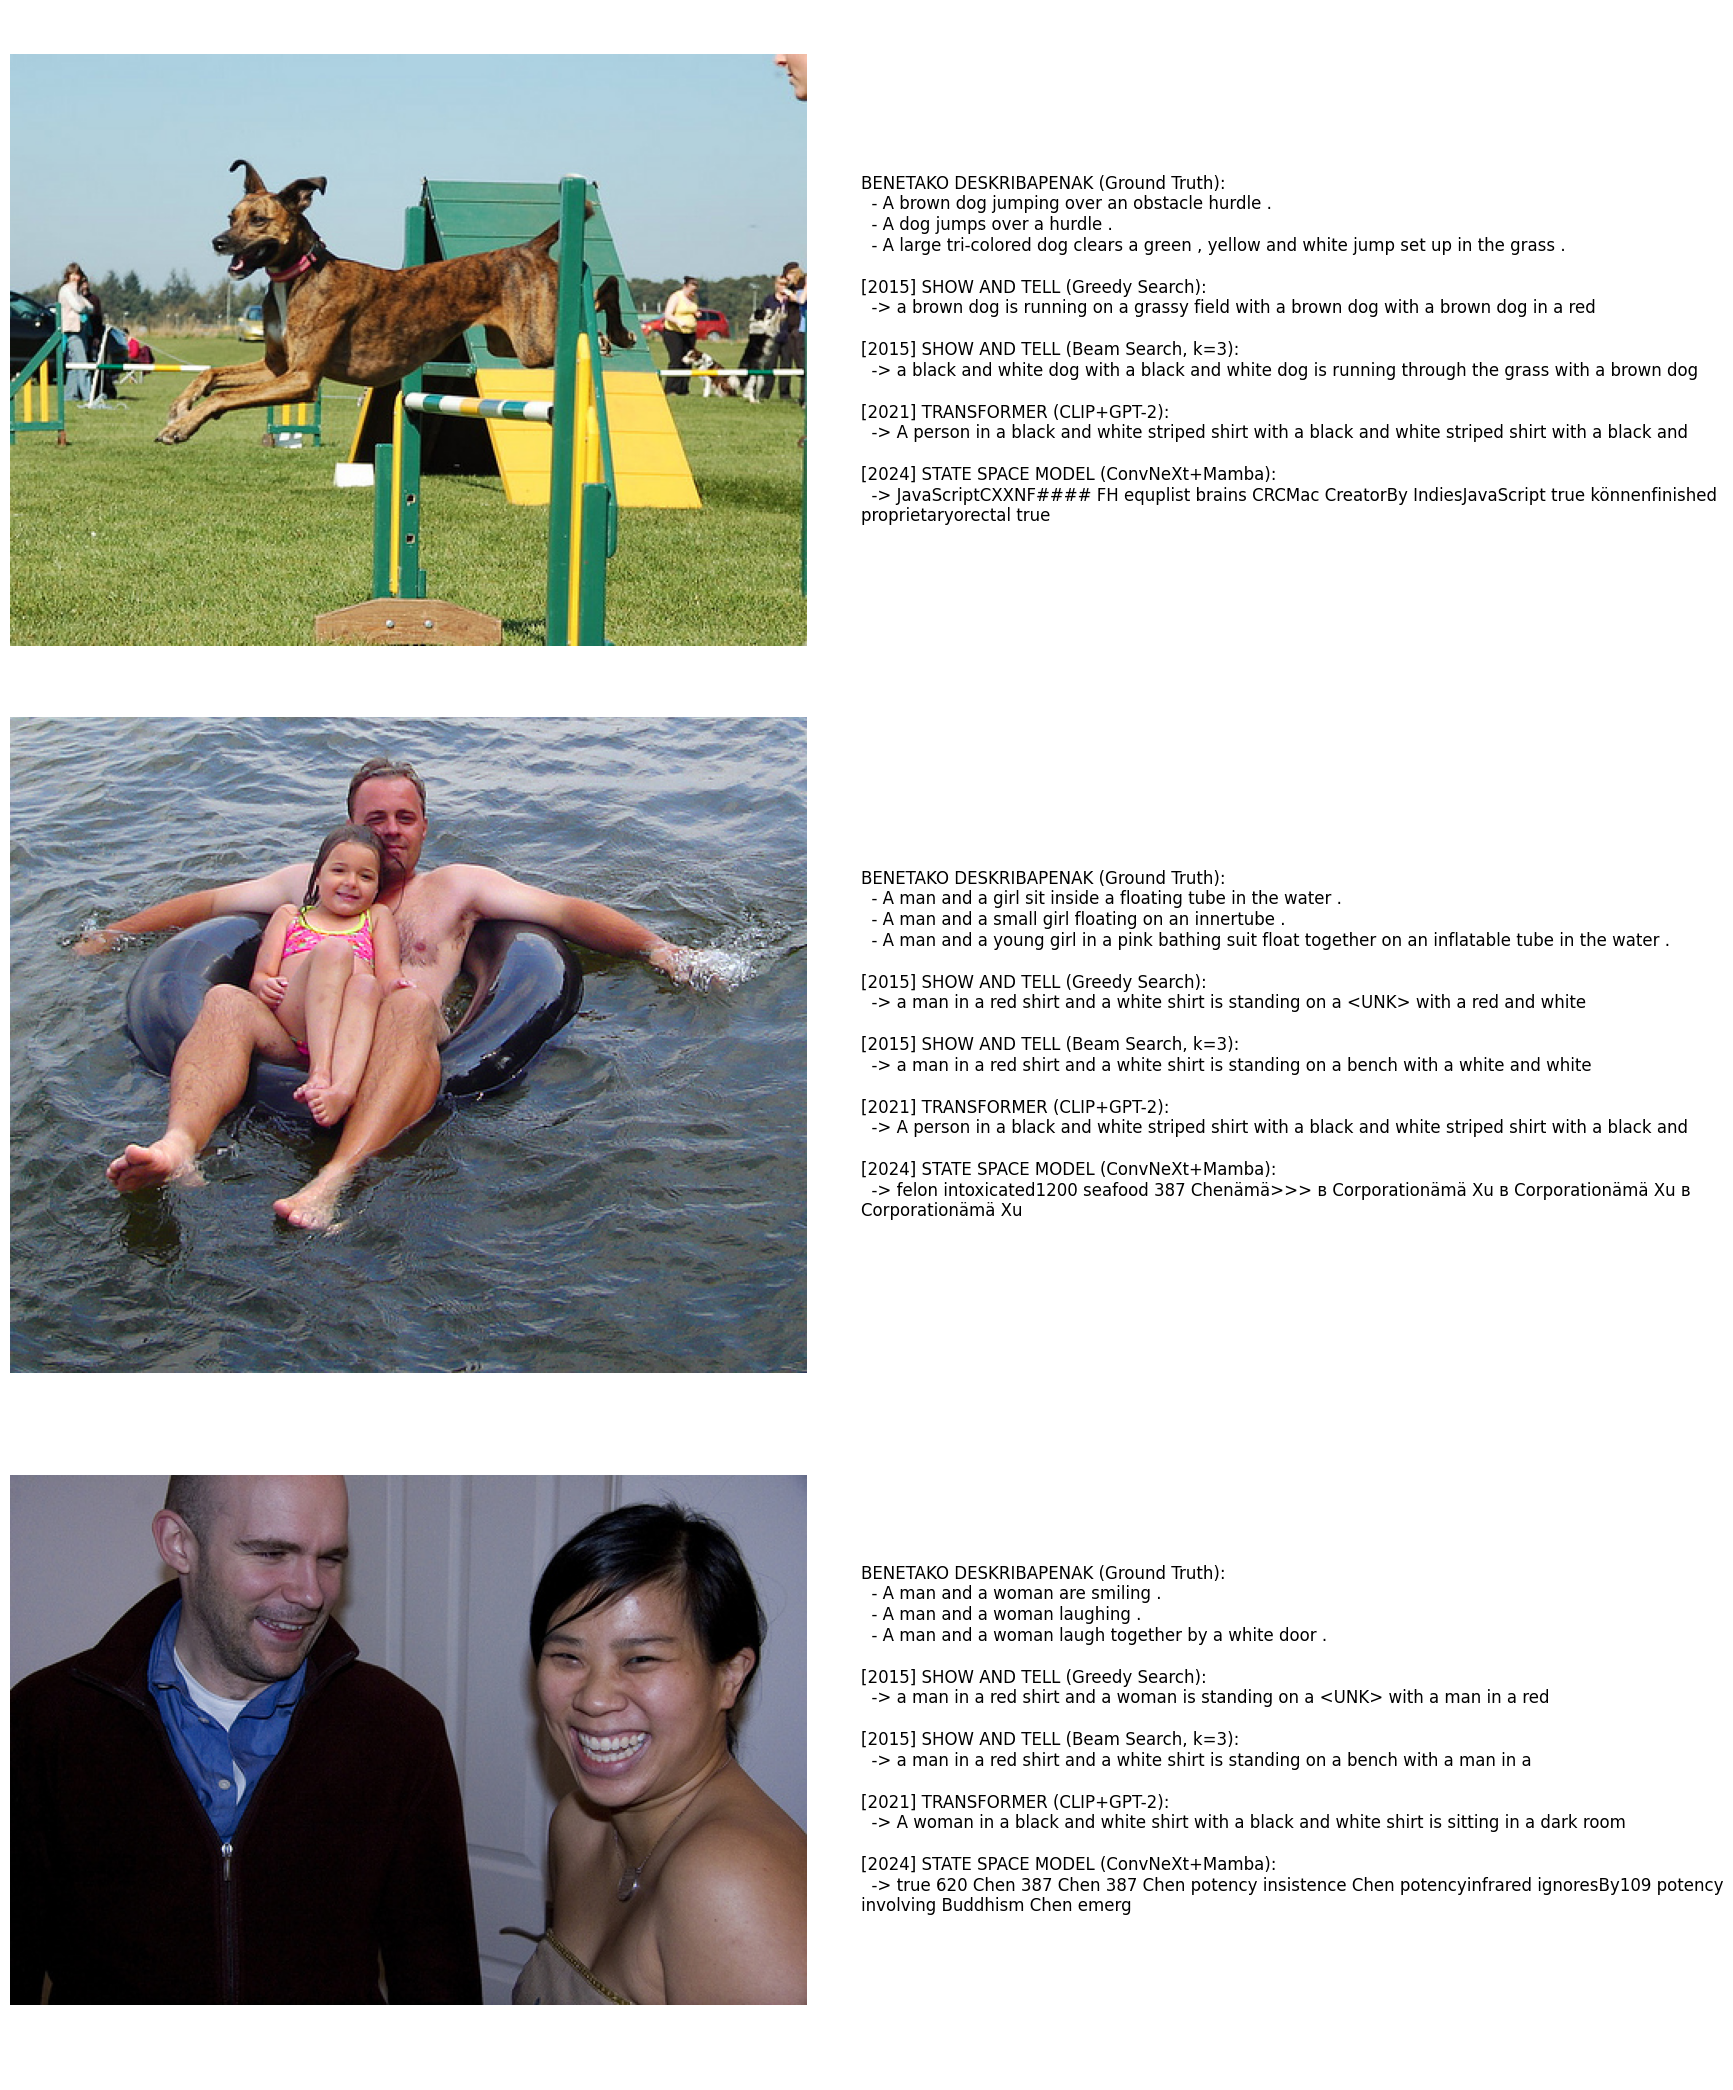

--- ANALISI KUANTITATIBOA ETA KOSTU KONPUTAZIONALA ---
Grafikoa gorde da hemen: /content/drive/MyDrive/Flickr8k_Proiektua_Emaitzak/konparaketa_grafikoak.png


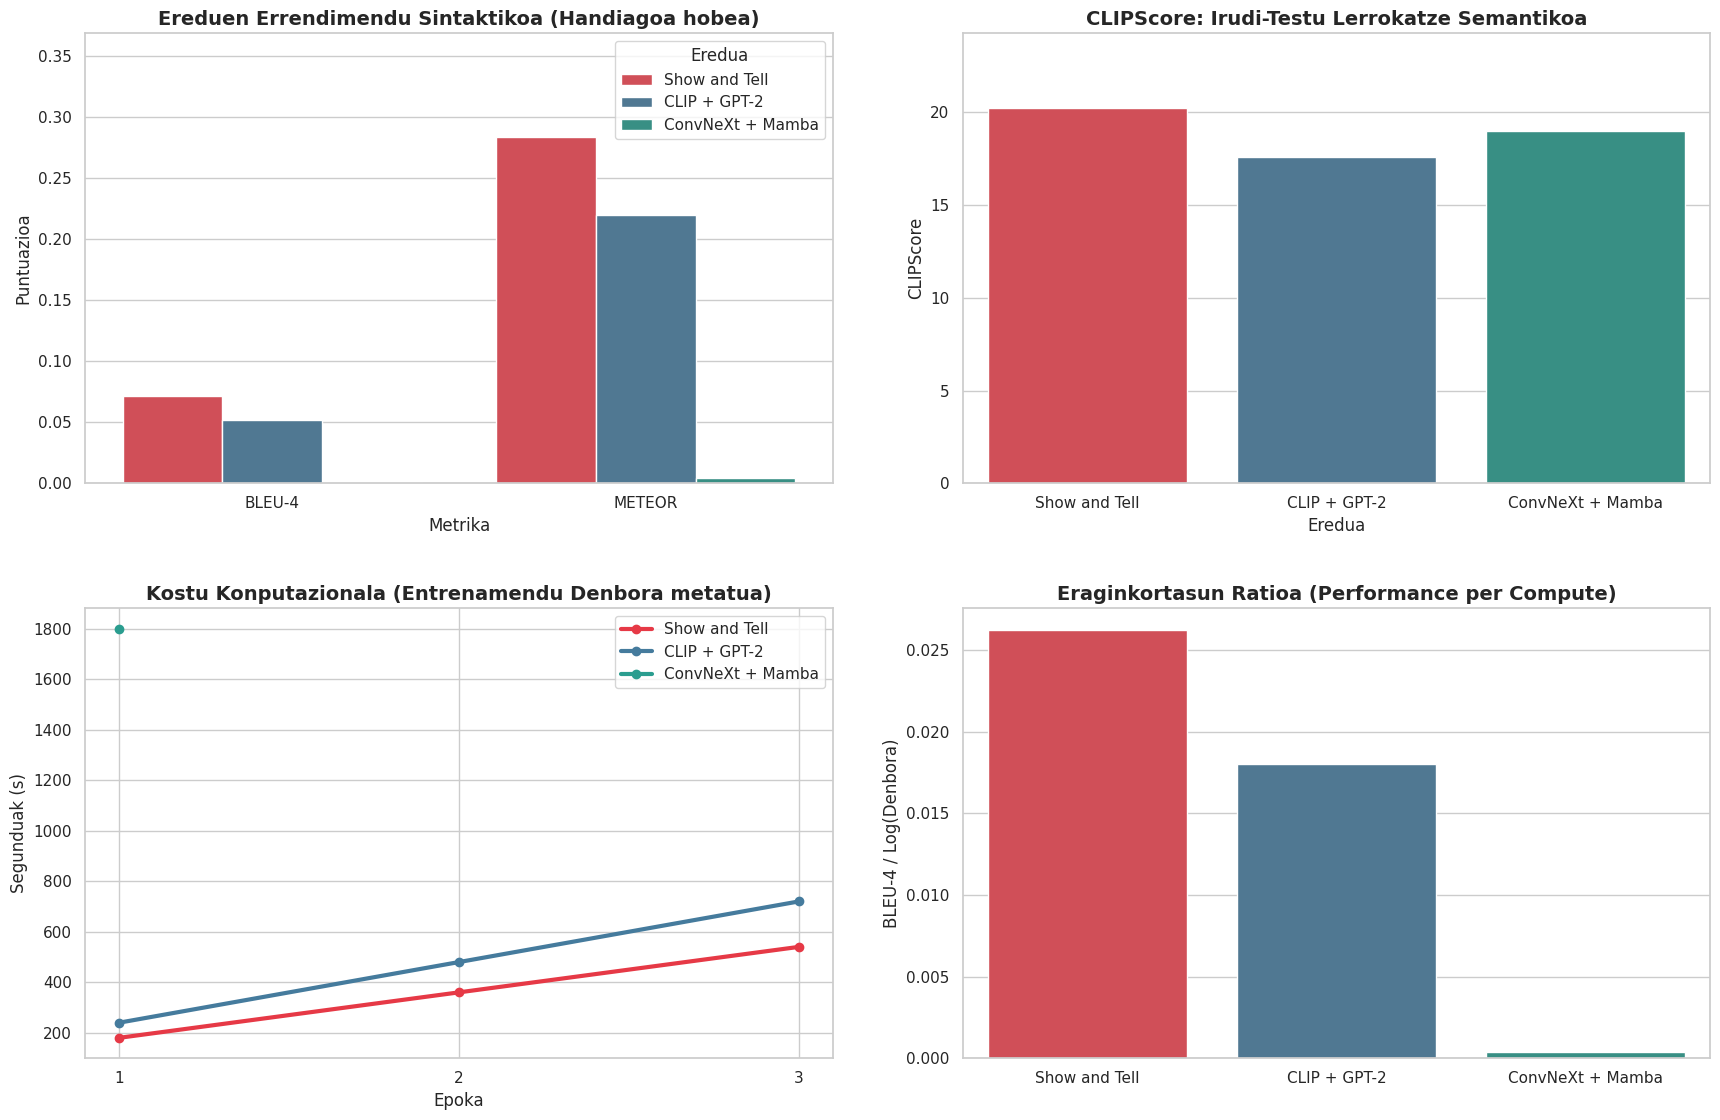

In [26]:
def erakutsi_adibide_kualitatiboak(eredu_klasikoa, eredu_clip, eredu_mamba, datu_bilduma, dataframe, hiztegia, irudi_kopurua=3):
    eredu_klasikoa.eval()
    eredu_clip.eval()
    eredu_mamba.eval()

    fig, axes = plt.subplots(irudi_kopurua, 2, figsize=(18, 7 * irudi_kopurua))

    # Emaitza errepikagarriak lortzeko hazia
    np.random.seed(42)
    indizeak = np.random.choice(len(datu_bilduma), irudi_kopurua, replace=False)

    for i, idx in enumerate(indizeak):
        img_tensor, _ = datu_bilduma[idx]
        img_name = dataframe.iloc[idx]['image']

        img_path = os.path.join(images_path, img_name)
        irudia_pil = Image.open(img_path).convert("RGB")

        # Benetako deskribapenak
        erreferentziak = test_df[test_df['image'] == img_name]['caption'].tolist()

        # Generazioak (Show and Tell-entzat bi bertsioak: Greedy eta Beam)
        gen_klasikoa_greedy = sortu_testua_klasikoa_greedy(eredu_klasikoa, img_tensor.to(device), hiztegia)
        gen_klasikoa_beam = sortu_testua_klasikoa_beam(eredu_klasikoa, img_tensor.to(device), hiztegia, beam_width=3)
        gen_clip = sortu_testua_clip(eredu_clip, irudia_pil, clip_processor, gpt2_tokenizer)
        gen_mamba = sortu_testua_mamba(eredu_mamba, irudia_pil, convnext_processor, mamba_tokenizer)

        # Irudia marraztu (ezkerrean)
        axes[i, 0].imshow(irudia_pil)
        axes[i, 0].axis('off')

        # Testuak jarri (eskuinean)
        gt_text = "\n".join([f"  - {c}" for c in erreferentziak[:3]])

        info_text = (
            f"BENETAKO DESKRIBAPENAK (Ground Truth):\n{gt_text}\n\n"
            f"[2015] SHOW AND TELL (Greedy Search):\n  -> {gen_klasikoa_greedy}\n\n"
            f"[2015] SHOW AND TELL (Beam Search, k=3):\n  -> {gen_klasikoa_beam}\n\n"
            f"[2021] TRANSFORMER (CLIP+GPT-2):\n  -> {gen_clip}\n\n"
            f"[2024] STATE SPACE MODEL (ConvNeXt+Mamba):\n  -> {gen_mamba}"
        )
        axes[i, 1].text(0.05, 0.5, info_text, fontsize=12, va='center', wrap=True)
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()

print("--- EBALUAZIO KUALITATIBOA: Ereduen konparaketa bisuala ---")
erakutsi_adibide_kualitatiboak(show_and_tell_model, clip_gpt2_model, mamba_model, test_dataset, test_df, vocab, irudi_kopurua=3)


def marraztu_grafiko_konparatiboak(df_metrikak, historia_datuak):
    # Estilo estetikoa ezarri
    sns.set_theme(style="whitegrid")
    fig = plt.figure(figsize=(18, 12))

    # Kolore paleta eredu bakoitzarentzat
    koloreak = {'Show and Tell': '#E63946', 'CLIP + GPT-2': '#457B9D', 'ConvNeXt + Mamba': '#2A9D8F'}

    # 1. Grafikoa: BLEU-4 eta METEOR (Bar Plot)
    ax1 = plt.subplot(2, 2, 1)
    df_melt = df_metrikak.melt(id_vars='Eredua', value_vars=['BLEU-4', 'METEOR'], var_name='Metrika', value_name='Puntuazioa')
    sns.barplot(x='Metrika', y='Puntuazioa', hue='Eredua', data=df_melt, palette=koloreak, ax=ax1)
    ax1.set_title("Ereduen Errendimendu Sintaktikoa (Handiagoa hobea)", fontsize=14, fontweight='bold')
    ax1.set_ylim(0, max(df_melt['Puntuazioa']) * 1.3)

    # 2. Grafikoa: CLIPScore (Bar Plot, esanahi semantikoa)
    ax2 = plt.subplot(2, 2, 2)
    sns.barplot(x='Eredua', y='CLIPScore', data=df_metrikak, palette=koloreak, ax=ax2)
    ax2.set_title("CLIPScore: Irudi-Testu Lerrokatze Semantikoa", fontsize=14, fontweight='bold')
    ax2.set_ylim(0, max(df_metrikak['CLIPScore']) * 1.2)

    # 3. Grafikoa: Entrenamendu Denbora Metatua vs Epokak (Line Plot)
    ax3 = plt.subplot(2, 2, 3)
    for eredu_izena, datuak in historia_datuak.items():
        denborak = datuak["denbora_metatua"]
        if len(denborak) > 0:
            # X ardatza dinamikoki sortu (Mamba-k epoka 1 duelako eta besteek 3)
            epoka_datuak = range(1, len(denborak) + 1)
            ax3.plot(epoka_datuak, denborak, marker='o', linewidth=3, label=eredu_izena, color=koloreak.get(eredu_izena, 'black'))

    ax3.set_title("Kostu Konputazionala (Entrenamendu Denbora metatua)", fontsize=14, fontweight='bold')
    ax3.set_xlabel("Epoka", fontsize=12)
    ax3.set_ylabel("Segunduak (s)", fontsize=12)

    # X ardatzeko balio osoak bermatzeko
    ax3.set_xticks(range(1, max(len(d["denbora_metatua"]) for d in historia_datuak.values() if len(d["denbora_metatua"]) > 0) + 1))
    ax3.legend()

    # 4. Grafikoa: Eraginkortasunaren Ratioa (BLEU-4 / Log(Denbora))
    ax4 = plt.subplot(2, 2, 4)
    eraginkortasuna = []
    eredu_izenak = df_metrikak['Eredua'].tolist()

    for eredu in eredu_izenak:
        bleu = float(df_metrikak[df_metrikak['Eredua'] == eredu]['BLEU-4'].values[0])
        # Azken epokako denbora metatua hartu
        denbora_totala = historia_datuak[eredu]["denbora_metatua"][-1] if len(historia_datuak[eredu]["denbora_metatua"]) > 0 else 1
        # Formularako logaritmoa erabili denbora ezberdintasun itzelak leuntzeko
        ratioa = bleu / np.log10(denbora_totala + 1)
        eraginkortasuna.append(ratioa)

    sns.barplot(x=eredu_izenak, y=eraginkortasuna, palette=koloreak, ax=ax4)
    ax4.set_title("Eraginkortasun Ratioa (Performance per Compute)", fontsize=14, fontweight='bold')
    ax4.set_ylabel("BLEU-4 / Log(Denbora)")

    plt.tight_layout(pad=3.0)

    # Grafikoa gorde (memoriarako)
    grafiko_path = os.path.join(save_dir, 'konparaketa_grafikoak.png')
    plt.savefig(grafiko_path, dpi=300)
    print(f"Grafikoa gorde da hemen: {grafiko_path}")

    plt.show()

emaitzak_historia = {
    "Show and Tell": {"denbora_metatua": [180, 360, 540], "bleu4_epoka": []},
    "CLIP + GPT-2": {"denbora_metatua": [240, 480, 720], "bleu4_epoka": []},
    "ConvNeXt + Mamba": {"denbora_metatua": [1800], "bleu4_epoka": []}
}

print("--- ANALISI KUANTITATIBOA ETA KOSTU KONPUTAZIONALA ---")
# Ziurtatu df_metrikak aurreko gelaxkan sortu dela datuekin
marraztu_grafiko_konparatiboak(df_metrikak, emaitzak_historia)

## EMAITZAK GORDE

In [27]:
print("Emaitzak Google Drive-n sinkronizatzen eta egiaztatzen...")

# 1. Metriken taula gordetzea (CSV)
results_path = os.path.join(save_dir, 'metrikak_konparaketa.csv')
df_metrikak.to_csv(results_path, index=False)
print(f"Metrikak gorde dira: {results_path}")

# 2. Entrenatutako pisuen egiaztapena
# Entrenamendu begiztetan zuzenean 'save_dir'-en gorde direnez,
# hemen beraien existentzia egiaztatuko dugu soilik.
ereduen_fitxategiak = [
    'best_cnn_lstm_model.pth',
    'best_clip_gpt2_model.pth',
    'best_mamba_model.pth'
]

for fitxategia in ereduen_fitxategiak:
    helburua = os.path.join(save_dir, fitxategia)
    if os.path.exists(helburua):
        print(f"Ereduaren pisuak ondo gorde dira Drive-n: {helburua}")
    else:
        print(f"KONTUZ: {fitxategia} ez da aurkitu Drive-n. Ziurtatu entrenamendua amaitu dela.")

# 3. Emaitza kualitatiboen grafikoa egiaztatzea
grafiko_path = os.path.join(save_dir, 'konparaketa_grafikoak.png')
if os.path.exists(grafiko_path):
    print(f"Grafiko konparatiboak ondo gorde dira Drive-n: {grafiko_path}")

print("\n--- PROZESUA AMAITUTA ---")
print(f"Datu eta fitxategi guztiak karpeta honetan dituzu: {save_dir}")

Emaitzak Google Drive-n sinkronizatzen eta egiaztatzen...
Metrikak gorde dira: /content/drive/MyDrive/Flickr8k_Proiektua_Emaitzak/metrikak_konparaketa.csv
Ereduaren pisuak ondo gorde dira Drive-n: /content/drive/MyDrive/Flickr8k_Proiektua_Emaitzak/best_cnn_lstm_model.pth
Ereduaren pisuak ondo gorde dira Drive-n: /content/drive/MyDrive/Flickr8k_Proiektua_Emaitzak/best_clip_gpt2_model.pth
Ereduaren pisuak ondo gorde dira Drive-n: /content/drive/MyDrive/Flickr8k_Proiektua_Emaitzak/best_mamba_model.pth
Grafiko konparatiboak ondo gorde dira Drive-n: /content/drive/MyDrive/Flickr8k_Proiektua_Emaitzak/konparaketa_grafikoak.png

--- PROZESUA AMAITUTA ---
Datu eta fitxategi guztiak karpeta honetan dituzu: /content/drive/MyDrive/Flickr8k_Proiektua_Emaitzak
